In [1]:
import cv2
import numpy as np
import os

In [2]:
img_path = "sar_1.jpg"
# img_path = "sar_1_gray.jpg"
image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [3]:
image_gray = np.array([
    [9, 7, 3, 5],
    [15, 2, 4, 8],
    [1, 3, 2, 1],
    [4, 7, 4, 7],
])

(4, 4) (4, 4)


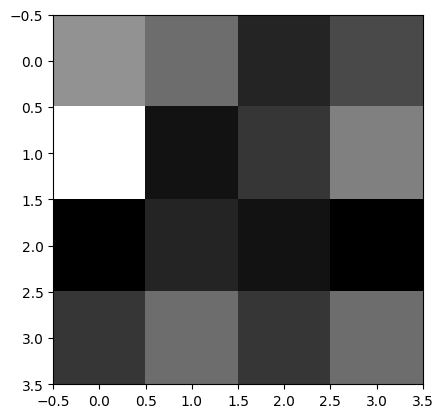

In [4]:
import numpy as np
import cv2 as cv2
from matplotlib import pyplot as plt
import seaborn as sns


def pad_to_multiple_of_2(image):
    h, w = image.shape
    h_new = h + (h % 2)
    w_new = w + (w % 2)
    
    padded = np.zeros((h_new, w_new), dtype=image.dtype)
    padded[:h, :w] = image
    return padded, (h, w)

image_padded, original_shape = pad_to_multiple_of_2(image_gray)

print(image_padded.shape, original_shape)

plt.imshow(image_padded, cmap="gray")

In [5]:
def dump_image(image_gray, original_file: str):
    with open(original_file, "wb") as f:
        for pixel in image_gray.flatten():
            f.write(bytes([int(pixel)]))

In [6]:
def haar_wavelet_1d(image):
    w = image.shape[0]
    w2 = w // 2

    result = np.zeros_like(image, dtype=np.float64)
    odds_row = image[::2]
    even_row = image[1::2]
    result[:w2] = (odds_row + even_row) / 2
    result[w2:] = (odds_row - even_row) / 2

    return result


def haar_wavelet_2d(image):
    h, w = image.shape
    h2, w2 = h // 2, w // 2

    temp = np.zeros_like(image, dtype=np.float64)
    result = np.zeros_like(image, dtype=np.float64)

    NORM = np.sqrt(2)
    NORM = 2

    # level 1
    odds_row = image[:, ::2]
    even_row = image[:, 1::2]
    temp[:, :w2] = (odds_row + even_row) / NORM
    temp[:, w2:] = (odds_row - even_row) / NORM

    odds_col = temp[::2, :]
    even_col = temp[1::2, :]
    result[:h2, :] = (odds_col + even_col) / NORM
    result[h2:, :] = (odds_col - even_col) / NORM

    return result


coeffs = haar_wavelet_2d(image_padded.astype(np.float64))
coeffs

array([[ 8.25,  5.  ,  3.75, -1.5 ],
       [ 3.75,  3.5 , -1.25, -0.5 ],
       [-0.25, -1.  , -2.75,  0.5 ],
       [-1.75, -2.  ,  0.25,  1.  ]])

In [7]:
def haar_wavelet_2d_inverse(coeffs):
    h, w = coeffs.shape
    h2, w2 = h // 2, w // 2

    NORM1 = np.sqrt(2)
    NORM2 = np.sqrt(2)

    NORM1 = np.sqrt(2)
    NORM2 = np.sqrt(2) / 2

    temp = np.zeros_like(coeffs, dtype=np.float64)
    temp[::2, :] = (coeffs[:h2, :] + coeffs[h2:, :]) / NORM1
    temp[1::2, :] = (coeffs[:h2, :] - coeffs[h2:, :]) / NORM1

    result = np.zeros_like(coeffs, dtype=np.float64)
    result[:, ::2] = (temp[:, :w2] + temp[:, w2:]) / NORM2
    result[:, 1::2] = (temp[:, :w2] - temp[:, w2:]) / NORM2

    return result

In [8]:
image_gray, haar_wavelet_2d_inverse(haar_wavelet_2d(image_gray))

(array([[ 9,  7,  3,  5],
        [15,  2,  4,  8],
        [ 1,  3,  2,  1],
        [ 4,  7,  4,  7]]),
 array([[ 9.,  7.,  3.,  5.],
        [15.,  2.,  4.,  8.],
        [ 1.,  3.,  2.,  1.],
        [ 4.,  7.,  4.,  7.]]))

In [9]:
image_gray[:, ::2], image_gray[:, 1::2]

(array([[ 9,  3],
        [15,  4],
        [ 1,  2],
        [ 4,  4]]),
 array([[7, 5],
        [2, 8],
        [3, 1],
        [7, 7]]))

In [10]:
image_gray[::2, :], image_gray[1::2, :]

(array([[9, 7, 3, 5],
        [1, 3, 2, 1]]),
 array([[15,  2,  4,  8],
        [ 4,  7,  4,  7]]))

In [11]:
haar_wavelet_1d(image_gray[0].astype(np.float64))

array([ 8.,  4.,  1., -1.])

In [12]:
coeffs[:2, 2:], coeffs[2:, :2], coeffs[2:, 2:]

(array([[ 3.75, -1.5 ],
        [-1.25, -0.5 ]]),
 array([[-0.25, -1.  ],
        [-1.75, -2.  ]]),
 array([[-2.75,  0.5 ],
        [ 0.25,  1.  ]]))

In [13]:
def threshold_detail_coefficients(coeffs, threshold):
    h, w = coeffs.shape
    h2, w2 = h // 2, w // 2

    thresholded = coeffs.copy()

    thresholded[:h2, w2:] = np.where(
        np.abs(thresholded[:h2, w2:]) < threshold, 0, thresholded[:h2, w2:]
    )
    thresholded[h2:, :w2] = np.where(
        np.abs(thresholded[h2:, :w2:]) < threshold, 0, thresholded[h2:, :w2:]
    )
    thresholded[h2:, w2:] = np.where(
        np.abs(thresholded[h2:, w2:]) < threshold, 0, thresholded[h2:, w2:]
    )

    return thresholded

threshold = 10
# threshold = 7
coeffs_thresholded = threshold_detail_coefficients(coeffs, threshold)
coeffs_thresholded

array([[8.25, 5.  , 0.  , 0.  ],
       [3.75, 3.5 , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  ]])

In [14]:
coeffs_rounded = np.round(coeffs_thresholded).astype(np.int32)
coeffs_rounded

array([[8, 5, 0, 0],
       [4, 4, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]], dtype=int32)

In [15]:
coeffs, haar_wavelet_2d_inverse(coeffs)

(array([[ 8.25,  5.  ,  3.75, -1.5 ],
        [ 3.75,  3.5 , -1.25, -0.5 ],
        [-0.25, -1.  , -2.75,  0.5 ],
        [-1.75, -2.  ,  0.25,  1.  ]]),
 array([[ 9.,  7.,  3.,  5.],
        [15.,  2.,  4.,  8.],
        [ 1.,  3.,  2.,  1.],
        [ 4.,  7.,  4.,  7.]]))

In [16]:
import struct


def dump_haar(data: np.array, compressed_file: str):
    def rle_encode(data):
        encoded = []
        zero_count = 0

        for value in data:
            if value == 0:
                zero_count += 1
            else:
                encoded.append((zero_count, int(value)))
                zero_count = 0

        if zero_count > 0:
            encoded.append((zero_count, 0))

        return encoded

    rle_data = rle_encode(data.flatten())

    # record_fmt = struct.Struct("<Ih")  # uint4, short
    # record_fmt = struct.Struct("<Hh")  # uint2, short
    # with open(compressed_file, "wb") as f:
    #     for zero_count, value in rle_data:
    #         f.write(record_fmt.pack(zero_count, value))

    def pack_rle_record(zero_count: int, value: int) -> bytes:
        return zero_count.to_bytes(3, "little", signed=False) + value.to_bytes(
            2, "little", signed=True
        )

    with open(compressed_file, "wb") as f:
        for z, v in rle_data:
            f.write(pack_rle_record(z, v))

    return rle_data

In [17]:
original_file = "orig.txt"
dump_image(image_gray, original_file)
compressed_file = "compressed.rle"
rle_data = dump_haar(coeffs_rounded, compressed_file)

In [18]:
original_size = os.path.getsize(original_file)
compressed_size = os.path.getsize(compressed_file)
original_size / compressed_size

0.64

In [19]:
# 1byte * (h * w)
# 1byte * nz + 2byte * nz

# (h * w) / (nz * 3) # compression
# nz >= (h / 2 * w / 2) = h * w
# => (h*w) / (h*w /4 * 3) = 4 / 3

In [20]:
original_size / image_gray.size, compressed_size / (len(rle_data))

(1.0, 5.0)

In [21]:
metrics = {
    q: {"ratios": [], "rmses": [], "psnrs": []}
    # for q in [0, 0.25, 0.5, 0.75, 0.9]
    for q in np.linspace(0, 1, 10)
}
from glob import glob

# images = ["sar_1.jpg", "sar_1_gray.jpg"]
images = glob("data/tmp/*_noised.png")[:10]

for img_path in images:
    image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    image_padded, original_shape = pad_to_multiple_of_2(image_gray)

    original_file = "orig.txt"
    dump_image(image_gray, original_file)

    coeffs = haar_wavelet_2d(image_padded.astype(np.float64))
    for threshold_q in metrics.keys():
        threshold = np.quantile(np.absolute(coeffs).flatten(), threshold_q)
        # print(threshold_q)
        coeffs_thresholded = threshold_detail_coefficients(coeffs, threshold)
        coeffs_rounded = np.round(coeffs_thresholded).astype(np.int32)

        compressed_file = "compressed.rle"
        rle_data = dump_haar(coeffs_rounded, compressed_file)
        # print("zc", rle_data[-1])

        original_size = os.path.getsize(original_file)
        compressed_size = os.path.getsize(compressed_file)

        # print(original_size / image_gray.size, compressed_size / (len(rle_data)))

        ratio = original_size / compressed_size

        image_restored = haar_wavelet_2d_inverse(coeffs_rounded.astype(np.float64))
        image_restored = np.clip(
            image_restored[: original_shape[0], : original_shape[1]], 0, 255
        ).astype(np.uint8)

        mse = np.mean(
            (image_gray.astype(np.float64) - image_restored.astype(np.float64)) ** 2
        )
        rmse = np.sqrt(mse)
        psnr = 10 * np.log10(255**2 / mse)

        # 2. Store metrics
        metrics[threshold_q]["ratios"].append(ratio)
        metrics[threshold_q]["rmses"].append(rmse)
        metrics[threshold_q]["psnrs"].append(psnr)

print('ratio, rmse, psnr')
for q in sorted(metrics.keys()):
    mean_ratio = np.mean(metrics[q]["ratios"])
    mean_rmse  = np.mean(metrics[q]["rmses"])
    mean_psnr  = np.mean(metrics[q]["psnrs"])
    print(mean_ratio, mean_rmse, mean_psnr)

ratio, rmse, psnr
0.23634929473912317 1.1016486870515725 47.29311087069018
0.23739375429461673 1.1055320000525204 47.262749963629304
0.2590301858843158 1.3129237738158352 45.82052902540817
0.29304062405085857 1.9915760367668351 42.49917812527203
0.3467768194734592 3.0884516573918868 39.059419486161985
0.4404611779167199 4.577649020971691 35.7784493503839
0.5937139986009197 6.791792600872924 32.18101730413137
0.7999902344942079 10.137081302945548 28.580696203139098
0.7999902344942079 10.137081302945548 28.580696203139098
0.7999902344942079 10.137081302945548 28.580696203139098


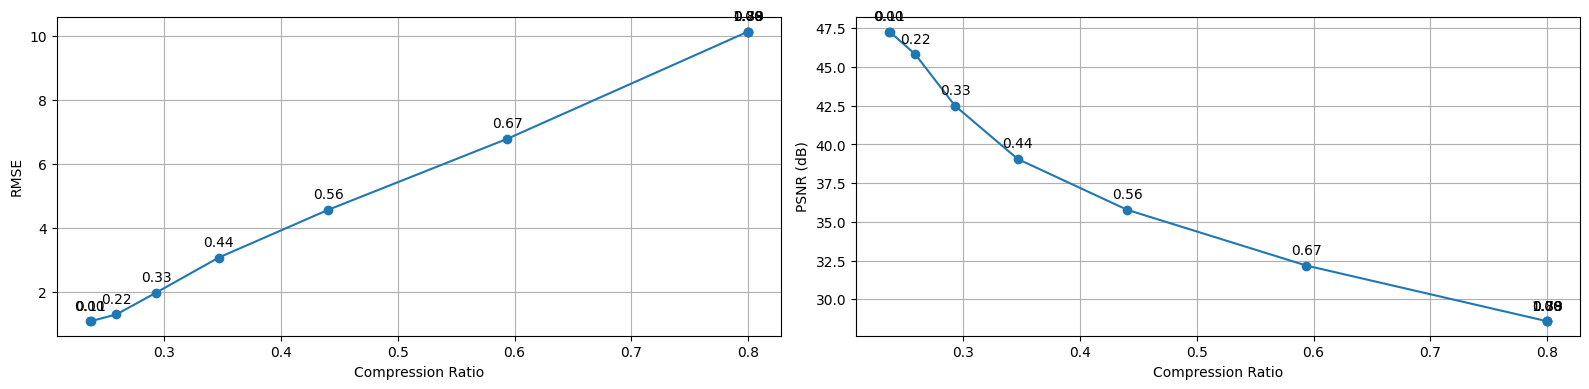

In [22]:
import matplotlib.pyplot as plt
import numpy as np

qs = sorted(metrics.keys())
ratios = [np.mean(metrics[q]["ratios"]) for q in qs]
rmses = [np.mean(metrics[q]["rmses"]) for q in qs]
psnrs = [np.mean(metrics[q]["psnrs"]) for q in qs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.plot(ratios, rmses, marker="o")
ax1.set_xlabel("Compression Ratio")
ax1.set_ylabel("RMSE")
ax1.grid(True)
for i, q in enumerate(qs):
    ax1.annotate(
        f"{q:.2f}",
        (ratios[i], rmses[i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

ax2.plot(ratios, psnrs, marker="o")
ax2.set_xlabel("Compression Ratio")
ax2.set_ylabel("PSNR (dB)")
ax2.grid(True)
for i, q in enumerate(qs):
    ax2.annotate(
        f"{q:.2f}",
        (ratios[i], psnrs[i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

plt.tight_layout()
plt.show()

<Axes: >

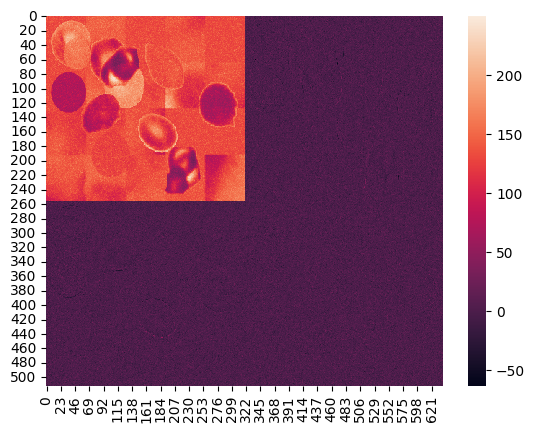

In [23]:
sns.heatmap(coeffs)

In [24]:
threshold

np.float64(249.75)

<Axes: >

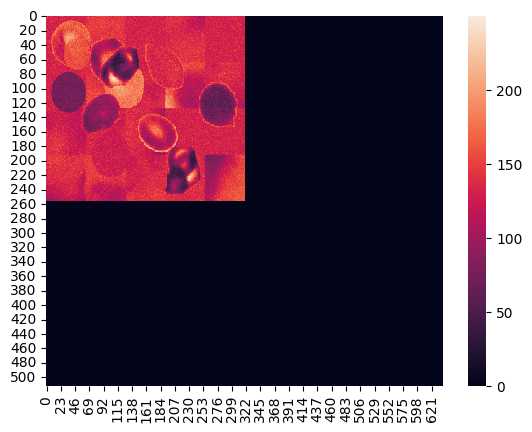

In [25]:
sns.heatmap(coeffs_thresholded)

<Axes: >

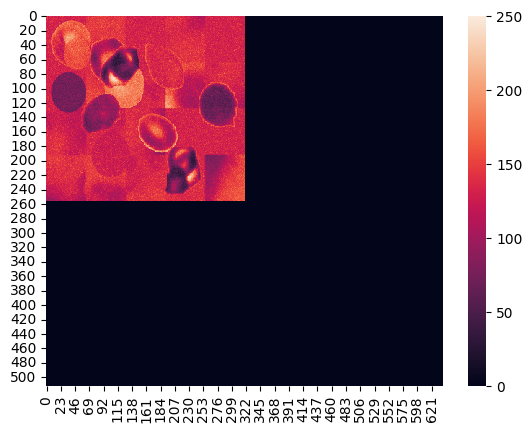

In [26]:
sns.heatmap(coeffs_rounded)

In [27]:
# def unpack_rle_record(chunk: bytes):
#     zero_count = int.from_bytes(chunk[:3], 'little', signed=False)
#     value = int.from_bytes(chunk[3:], 'little', signed=True)
#     return zero_count, value

# with open(compressed_file, "rb") as f:
#     while chunk := f.read(5):  # 5 bytes per record
#         if len(chunk) < 5:
#             break  # Handle truncated file
#         z, v = unpack_rle_record(chunk)

# with open(original_file, "rb") as f:
#     pixels = np.frombuffer(f.read(), dtype=np.uint8)
# image_gray_reconstructed = pixels.reshape(original_shape)

In [28]:
image_restored = haar_wavelet_2d_inverse(coeffs_rounded.astype(np.float64))
# image_restored = haar_wavelet_2d_inverse(coeffs)
image_restored = np.clip(
    image_restored[: original_shape[0], : original_shape[1]], 0, 255
).astype(np.uint8)

In [29]:
image_restored, image_gray

(array([[130, 130, 121, ..., 132, 137, 137],
        [130, 130, 121, ..., 132, 137, 137],
        [132, 132, 139, ..., 127, 129, 129],
        ...,
        [105, 105,  82, ..., 161, 159, 159],
        [ 90,  90, 100, ..., 165, 169, 169],
        [ 90,  90, 100, ..., 165, 169, 169]], shape=(512, 640), dtype=uint8),
 array([[122, 124, 122, ..., 154, 122, 122],
        [136, 141, 122, ..., 122, 182, 125],
        [149, 139, 148, ..., 122, 122, 137],
        ...,
        [ 92,  88,  82, ..., 154, 154, 176],
        [ 81, 106, 149, ..., 188, 195, 175],
        [ 81,  97,  80, ..., 154, 154, 154]], shape=(512, 640), dtype=uint8))

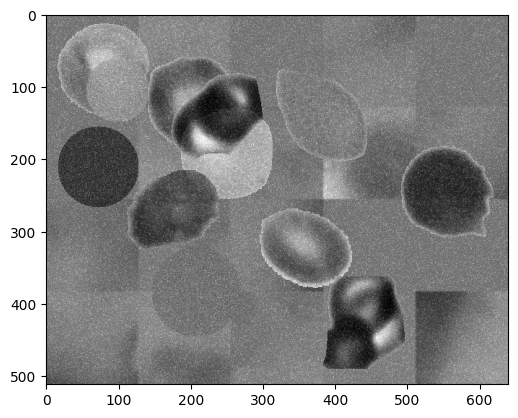

In [30]:
plt.imshow(image_gray, cmap="gray")

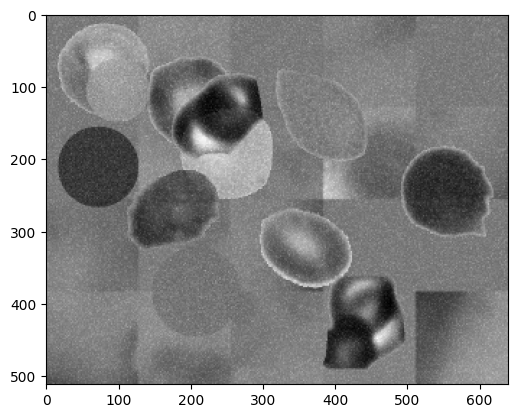

In [31]:
plt.imshow(image_restored, cmap="gray")

In [32]:
mse = np.mean((image_gray.astype(np.float64) - image_restored.astype(np.float64)) ** 2)

np.sqrt(mse), 10 * np.log10(255**2 / mse)

(np.float64(13.166714310056866), np.float64(25.741255360835765))